# MiMICS — interactive demo

This notebook **checks each layer** (Java gateway + Py4J + COBRApy + outputs), runs a **short** P. aeruginosa example, **plots** agents and metabolite fields, and writes CSVs under a dedicated output folder.

**Setup:** run section 1 to install Python packages, fetch Py4J, clone HAL, and compile Java. You need a **JDK** (`javac` on `PATH`) and network on first run. The gateway listens on **25333** (Py4J default).

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repository root: cwd, or parent if cwd is notebooks/
REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import mimics_demo_helpers as mdh

if not (REPO / "Example_P. aeruginosa biofilm").is_dir():
    REPO = mdh.find_repo_root(Path.cwd())

EXAMPLE = REPO / "Example_P. aeruginosa biofilm"
OUTPUT_SUBDIR = "notebook_demo_out/"
JOB_NUM = 0

gateway_proc = None  # set when you start the Java gateway cell

print("REPO =", REPO)
print("EXAMPLE =", EXAMPLE)

REPO = /Users/zachrobers/Coursework/Duke/Mathematics/MATH477/mimics_proteomics
EXAMPLE = /Users/zachrobers/Coursework/Duke/Mathematics/MATH477/mimics_proteomics/Example_P. aeruginosa biofilm


## 1. Prepare dependencies (Python + Java)

The next cell runs **`ensure_mimics_demo_ready`**: `pip install` for required packages, downloads a **Py4J** jar into `_jars/` if needed, **clones HAL** into `_deps_HAL/` if missing, patches **`GetAgentsRadApprox` → `public`** when needed, and runs **`javac`** for HAL and MiMICS.

Requires **network** the first time (pip / git clone / jar). Requires a **JDK** with `javac` on your `PATH`. To skip automatic `pip install` or HAL clone, call `mdh.ensure_mimics_demo_ready(REPO, install_python=False)` or `fetch_hal=False`.

In [2]:
# Automated setup: pip packages, Py4J jar, HAL clone, HAL/MiMICS javac (needs JDK + network first run)
ok, lines = mdh.ensure_mimics_demo_ready(REPO)
for line in lines:
    print(line)
print("Build OK:", ok)

def check_py(name: str, import_fn):
    try:
        import_fn()
        print(f"OK  Python: {name}")
        return True
    except Exception as e:
        print(f"FAIL Python: {name}: {e}")
        return False

check_py("cobra", lambda: __import__("cobra"))
check_py("py4j", lambda: __import__("py4j"))
check_py("openpyxl", lambda: __import__("openpyxl"))

if not ok:
    raise RuntimeError("Build check failed after ensure_mimics_demo_ready; see messages above.")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip


pip install: cobra pandas numpy openpyxl py4j matplotlib
Py4J jar: /Users/zachrobers/Coursework/Duke/Mathematics/MATH477/mimics_proteomics/_jars/py4j-0.10.9.7.jar
OK  HAL compiled classes: /Users/zachrobers/Coursework/Duke/Mathematics/MATH477/mimics_proteomics/_hal_classes/HAL
OK  MiMICS compiled classes: /Users/zachrobers/Coursework/Duke/Mathematics/MATH477/mimics_proteomics/_mimics_classes/MIMICS
OK  HAL dependency tree (_deps_HAL): /Users/zachrobers/Coursework/Duke/Mathematics/MATH477/mimics_proteomics/_deps_HAL/HAL
OK  Py4J jar: /Users/zachrobers/Coursework/Duke/Mathematics/MATH477/mimics_proteomics/_jars/py4j-0.10.9.7.jar
OK  MiMICS agent class: /Users/zachrobers/Coursework/Duke/Mathematics/MATH477/mimics_proteomics/_mimics_classes/MIMICS/Cell3D_PA.class
Build OK: True
OK  Python: cobra
OK  Python: py4j
OK  Python: openpyxl


## If build check fails with missing `Cell3D_PA.class`

Run this once in a terminal from repo root to rebuild MiMICS classes:

```bash
REPO="/Users/zachrobers/Coursework/Duke/Mathematics/MATH477/mimics_proteomics"
mkdir -p "$REPO/_java_mimics/MIMICS"
cp "$REPO/Example_P. aeruginosa biofilm/MIMICS_PA.java" "$REPO/Example_P. aeruginosa biofilm/MIMICS_gateway_PA.java" "$REPO/_java_mimics/MIMICS/"
PY4J_JAR="$REPO/_jars/py4j-0.10.9.7.jar"
rm -rf "$REPO/_mimics_classes"
mkdir -p "$REPO/_mimics_classes"
javac -encoding UTF-8 -cp "$REPO/_hal_classes:$PY4J_JAR" -d "$REPO/_mimics_classes" \
  "$REPO/_java_mimics/MIMICS/MIMICS_PA.java" \
  "$REPO/_java_mimics/MIMICS/MIMICS_gateway_PA.java"
ls "$REPO/_mimics_classes/MIMICS"
```

You should see `Cell3D_PA.class` in that folder before continuing.

## 2. Short-run ABM spreadsheet

Copies `ABM_inputs.xlsx` to `notebook_demo_ABM.xlsx` with a small `total_sim_time` and `time_step` so **`num_dt = total_sim_time * 60 / time_step`** is small (default **5** steps). Adjust `DEMO_STEPS` if needed.

In [3]:
DEMO_STEPS = 5
TIME_STEP_MIN = 0.6
TOTAL_SIM_HOURS = DEMO_STEPS * TIME_STEP_MIN / 60.0

abm_src = EXAMPLE / "ABM_inputs.xlsx"
abm_demo = EXAMPLE / "notebook_demo_ABM.xlsx"

abm = pd.read_excel(abm_src, engine="openpyxl")
abm = abm.set_index("Parameter name")
abm.loc["total_sim_time", "Parameter value"] = TOTAL_SIM_HOURS
abm.loc["time_step", "Parameter value"] = TIME_STEP_MIN
abm = abm.reset_index()
abm.to_excel(abm_demo, index=False)

num_dt = TOTAL_SIM_HOURS * 60 / TIME_STEP_MIN
print(f"Wrote {abm_demo.name}; num_dt ≈ {num_dt}")

Wrote notebook_demo_ABM.xlsx; num_dt ≈ 5.0


## 3. Start the Java Py4J gateway

This cell stops the previous `gateway_proc` (if any) and frees port **25333** (kills stray `java` listeners) before starting a new gateway, so you can re-run it without manual `lsof` / `kill`.

In [4]:
mdh.stop_gateway(globals().get("gateway_proc"))
gateway_proc = mdh.start_gateway(REPO, sleep_sec=12.0)
print("Gateway PID:", gateway_proc.pid, "(leave running for the next cell)")

Gateway PID: 89206 (leave running for the next cell)


## 4. Run the Python driver (`agents_FBA_PA.py`)

This sets **`MIMICS_DEMO_SHORT=1`** so metabolite / flux snapshots are saved **every** time step for this short run. Outputs go under **`notebook_demo_out/`** in the example folder. The driver converts that to an **absolute path** so Java (gateway cwd = repo root) writes CSVs to the same folder as Python.

In [5]:
env = os.environ.copy()
env["MIMICS_DEMO_SHORT"] = "1"
env["MIMICS_ABM_FILE"] = "notebook_demo_ABM.xlsx"
env["MIMICS_OUTPUT_DIR"] = OUTPUT_SUBDIR
env["MIMICS_NCPUS"] = "2"

r = subprocess.run(
    [sys.executable, "agents_FBA_PA.py"],
    cwd=str(EXAMPLE),
    env=env,
    capture_output=True,
    text=True,
)
print("returncode", r.returncode)
print(r.stdout[-4000:] if r.stdout else "")
print(r.stderr[-2000:] if r.stderr else "")
if r.returncode != 0:
    raise RuntimeError("agents_FBA_PA.py failed; see stdout/stderr above.")

returncode 0
MiMICS python file started
User inputs defined
ABM parameters imported
Metabolite PDE grid conditions imported
Metabolic models imported
Reaction IDs imported
Agent-based model and reaction-diffusion model initialized
Run MiMICS simulation
Multiprocessing worker initialized
Multiprocessing worker initialized
MiMICS simulation finished




## 5. Load outputs and plot

- **Agents:** `agent_properties{job}.csv` — positions, metabolic state, local metabolites.
- **Metabolite grid:** `met_grid{job}.csv` — full 3D field (can be large).
- **Fluxes:** `rxns_flux{job}.csv` — reaction fluxes per agent at saved times.

In [6]:
out = EXAMPLE / OUTPUT_SUBDIR
agent_path = out / f"agent_properties{JOB_NUM}.csv"
met_path = out / f"met_grid{JOB_NUM}.csv"
flux_path = out / f"rxns_flux{JOB_NUM}.csv"

for p in (agent_path, met_path, flux_path):
    print(p.name, p.stat().st_size if p.exists() else "MISSING")

# index_col=False is required: at t=0 every row has time==0; pandas would otherwise
# use the first column as the row index and shift all fields (looks like "no agents").
agents = pd.read_csv(agent_path, index_col=False)
agents = agents.loc[:, ~agents.columns.str.contains("^Unnamed")]
for c in ("time", "job_num", "cell index", "xcor", "ycor", "zcor", "metabolic_state"):
    if c in agents.columns:
        agents[c] = pd.to_numeric(agents[c], errors="coerce")
print("rows:", len(agents), "| rows at t=0:", int((agents["time"] == 0).sum()) if "time" in agents.columns else "?")
agents.head()

agent_properties0.csv 3629
met_grid0.csv 112387161
rxns_flux0.csv 8893


,time,job_num,cell index,xcor,ycor,zcor,metabolic_state,biomass,growth_rate,oxygen,nitric oxide,nitrate,glucose
0.0,0.0,0.0,61.523523,46.397106,0.0,0.0,2.137400e-12,1.039479,0.25,0.0,0.35,3.198250,NaN
0.0,0.0,1.0,21.941594,23.366231,0.0,0.0,1.759500e-12,1.065484,0.25,0.0,0.35,3.198525,NaN
0.0,0.0,2.0,46.520663,70.752484,0.0,0.0,1.759500e-12,1.065484,0.25,0.0,0.35,3.198525,NaN
0.0,0.0,3.0,113.813234,57.625194,0.0,0.0,1.835100e-12,1.059416,0.25,0.0,0.35,3.197611,NaN
0.0,0.0,4.0,69.906064,10.728990,0.0,0.0,1.366800e-12,1.071717,0.25,0.0,0.35,3.198847,NaN


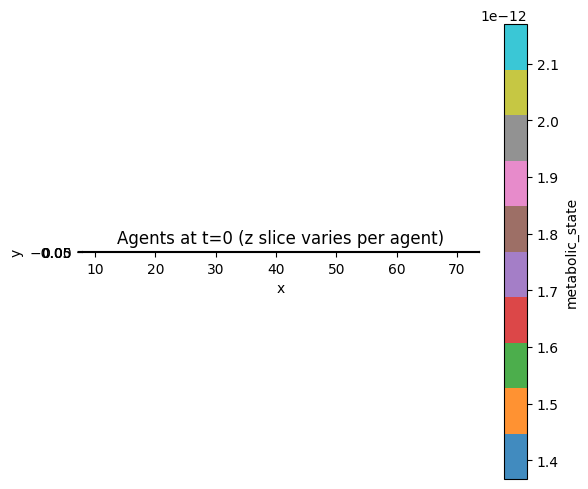

In [7]:
# Plot one timestep (prefer last). Use isclose because times are floats from CSV.
t_last = float(agents["time"].max())
last = agents[np.isclose(agents["time"].astype(float), t_last)]
if last.empty:
    last = agents[agents["time"] == 0]
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    last["xcor"].astype(float),
    last["ycor"].astype(float),
    c=last["metabolic_state"].astype(float),
    cmap="tab10",
    s=36,
    alpha=0.85,
)
plt.colorbar(sc, ax=ax, label="metabolic_state")
ax.set_aspect("equal")
ax.set_xlabel("x (patch coords)")
ax.set_ylabel("y (patch coords)")
ax.set_title(f"Agents (n={len(last)}) at t≈{t_last:g}")
plt.tight_layout()
plt.show()

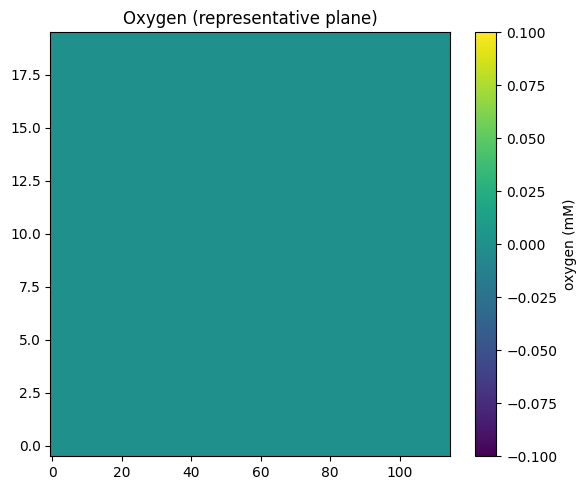

In [8]:
# Oxygen field on z=0 plane at t==0
met = pd.read_csv(met_path, index_col=False)
met = met.loc[:, ~met.columns.str.contains("^Unnamed")]
m0 = met[(met["time"] == 0) & (met["zcor"] == 0)]
if len(m0) == 0:
    m0 = met[met["time"] == 0]
    z0 = m0["zcor"].median()
    m0 = met[(met["time"] == 0) & (met["zcor"] == z0)]

pivot = m0.pivot_table(index="ycor", columns="xcor", values="oxygen", aggfunc="first")
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot.values, origin="lower", aspect="auto", cmap="viridis")
plt.colorbar(im, ax=ax, label="oxygen (mM)")
ax.set_title("Oxygen (representative plane)")
plt.tight_layout()
plt.show()

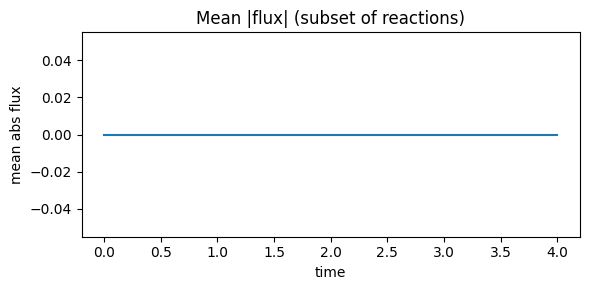

,time,job_num,cell index,rJB00269,rxn12498,rxn00567,rJB00274,rJB00273,rxn13864,rxn_os,...,rxn13860,rxn13855,rxn13925,rxn13841,rxn11546,rxn04093,rxn04092,rxn00269,EX_cpd00418_e,abs_sum
0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
flux = pd.read_csv(flux_path, index_col=False)
flux = flux.loc[:, ~flux.columns.str.contains("^Unnamed")]
# Sum absolute flux as a simple activity scalar (first few reaction columns only)
rxn_cols = [c for c in flux.columns if c not in ("time", "job_num", "cell index")][:8]
if rxn_cols:
    flux["abs_sum"] = flux[rxn_cols].abs().sum(axis=1)
    ts = flux.groupby("time")["abs_sum"].mean()
    ts.plot(title="Mean |flux| (subset of reactions)", figsize=(6, 3))
    plt.ylabel("mean abs flux")
    plt.tight_layout()
    plt.show()

flux.head()

## 6. Stop the gateway

Run when finished (or close the kernel, which may leave a stray Java process).

In [10]:
proc = globals().get("gateway_proc")
mdh.stop_gateway(proc)
print("Stopped (no-op if gateway was not started).")

Stopped (no-op if gateway was not started).
